In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('train.csv')

# --- Preprocessing (same as your Phase 1/2) ---
df.Gender = df.Gender.fillna('Male')
df.Married = df.Married.fillna('Yes')
df.Dependents = df.Dependents.fillna('0')
df.Self_Employed = df.Self_Employed.fillna('No')
df.LoanAmount = df.LoanAmount.fillna(df.LoanAmount.mean())
df.Loan_Amount_Term = df.Loan_Amount_Term.fillna(360.0)
df.Credit_History = df.Credit_History.fillna(1.0)

# Split X and y
X = df.drop(['Loan_Status', 'Loan_ID'], axis=1)
X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(df['Loan_Status'])

In [2]:
# --- Phase 3: Split Ratio Comparison using SVM ---

def run_svm(test_size, train_list, test_list):
    print(f"\n--- Split Ratio {int((1-test_size)*100)}:{int(test_size*100)} ---")

    # Data split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Feature Scaling (required for SVM)
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)

    # Model train
    svm = SVC(kernel='rbf', C=1, gamma='scale')
    svm.fit(X_train_scaled, y_train)

    # Predictions
    train_pred = svm.predict(X_train_scaled)
    test_pred = svm.predict(X_test_scaled)

    # Evaluation
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print(classification_report(y_test, test_pred))

    train_list.append(train_acc)
    test_list.append(test_acc)

    return train_list, test_list


results_svm = {}

train_scores = []
test_scores = []

train_scores, test_scores = run_svm(0.4, train_scores, test_scores)
train_scores, test_scores = run_svm(0.3, train_scores, test_scores)
train_scores, test_scores = run_svm(0.2, train_scores, test_scores)

results_svm["train"] = train_scores
results_svm["test"] = test_scores


--- Split Ratio 60:40 ---
Train Accuracy: 0.8315217391304348
Test Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.92      0.42      0.58        85
           1       0.76      0.98      0.86       161

    accuracy                           0.79       246
   macro avg       0.84      0.70      0.72       246
weighted avg       0.82      0.79      0.76       246


--- Split Ratio 70:30 ---
Train Accuracy: 0.8321678321678322
Test Accuracy: 0.7783783783783784
              precision    recall  f1-score   support

           0       0.93      0.40      0.56        65
           1       0.75      0.98      0.85       120

    accuracy                           0.78       185
   macro avg       0.84      0.69      0.71       185
weighted avg       0.81      0.78      0.75       185


--- Split Ratio 80:20 ---
Train Accuracy: 0.8329938900203666
Test Accuracy: 0.7967479674796748
              precision    recall  f1-score   support

   

In [3]:
print(train_scores)
print(test_scores)

[0.8315217391304348, 0.8321678321678322, 0.8329938900203666]
[0.7886178861788617, 0.7783783783783784, 0.7967479674796748]


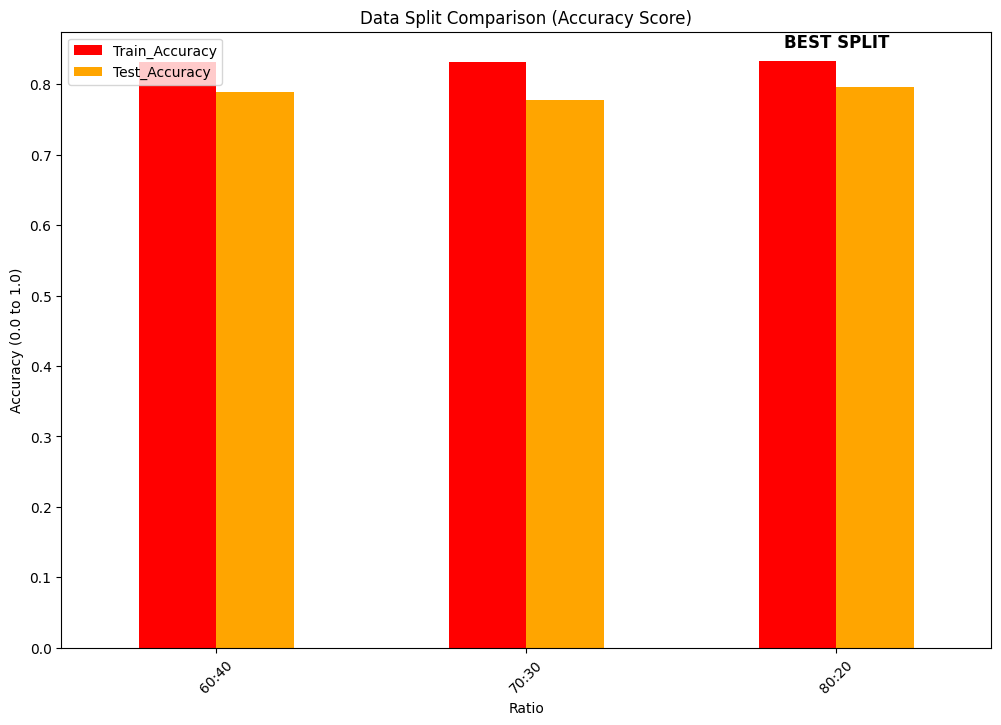

In [4]:
# --- Bar Chart: Split Ratio Comparison ---

data = {
    'Ratio': ['60:40', '70:30', '80:20'],
    'Train_Accuracy': train_scores,
    'Test_Accuracy': test_scores,
}

df_results = pd.DataFrame(data)

ax = df_results.plot(
    x='Ratio',
    y=['Train_Accuracy', 'Test_Accuracy'],
    kind='bar',
    figsize=(12, 8),
    color=['red', 'orange']
)

plt.title('Data Split Comparison (Accuracy Score)')
plt.ylabel('Accuracy (0.0 to 1.0)')
plt.xticks(rotation=45)

last_x = len(df_results) - 1
y_max = max(df_results['Train_Accuracy'].iloc[-1], df_results['Test_Accuracy'].iloc[-1])

plt.text(
    last_x,
    y_max + 0.02,
    "BEST SPLIT",
    ha='center',
    fontsize=12,
    fontweight='bold'
)

plt.show()

In [5]:
# --- Final Model Training with Best Split (80:20) ---

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

fin_model = SVC(kernel='rbf', C=1, gamma='scale')
fin_model.fit(X_train_scaled, y_train)

y_pred = fin_model.predict(X_test_scaled)

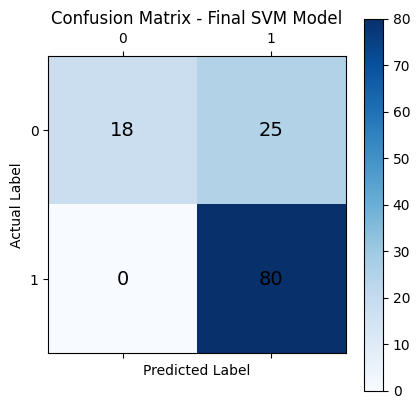

In [6]:
# --- Confusion Matrix Visualization ---

cm = confusion_matrix(y_test, y_pred)

plt.matshow(cm, cmap='Blues')
plt.title("Confusion Matrix - Final SVM Model")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=14)

plt.show()

In [7]:
# --- User Input: Predict Loan Status ---

def get_user_input(feature_columns):
    print("\nEnter applicant details:\n")

    raw = {}
    raw['Gender']            = input("Gender (Male/Female): ")
    raw['Married']           = input("Married (Yes/No): ")
    raw['Dependents']        = input("Dependents (0/1/2/3+): ")
    raw['Education']         = input("Education (Graduate/Not Graduate): ")
    raw['Self_Employed']     = input("Self Employed (Yes/No): ")
    raw['ApplicantIncome']   = float(input("Applicant Income: "))
    raw['CoapplicantIncome'] = float(input("Coapplicant Income: "))
    raw['LoanAmount']        = float(input("Loan Amount: "))
    raw['Loan_Amount_Term']  = float(input("Loan Amount Term (e.g. 360): "))
    raw['Credit_History']    = float(input("Credit History (1.0 / 0.0): "))
    raw['Property_Area']     = input("Property Area (Urban/Semiurban/Rural): ")

    # Encode same as training data
    input_df = pd.DataFrame([raw])
    input_df = pd.get_dummies(input_df, drop_first=True)

    # Align columns with training data
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    # Scale using the same scaler fitted on training data
    input_scaled = sc.transform(input_df)

    return input_scaled


def predict_loan_status(input_scaled):
    prediction = fin_model.predict(input_scaled)[0]
    label = le.inverse_transform([prediction])[0]
    return label


user_input = get_user_input(X.columns)

result = predict_loan_status(user_input)

print("\n Prediction Result")
print(f"Loan Status: {result}")


Enter applicant details:


 Prediction Result
Loan Status: Y
